# Junior AI Investigator: the analysis behind the app

This notebook is my working. I did it before designing any screen: read the question, look at the data, find its structure, decide what the data can and cannot support, then build. It imports `triage.py` and `ai.py`, the same code the app runs, so the notebook and the app cannot drift apart.

**The question.** Investigators get a daily queue of referred claims and lose most of their time on cases that turn out to be benign. Can an AI do the first pass (sort the queue, explain each case, propose a next step) while the human stays in control?

**What the data can support.** 50 synthetic referrals, 10 signals, no outcomes. So no supervised model and no probability of fraud. Every row was already flagged by an upstream engine, so anything relative describes this queue, not all claims. What is left is a measurement problem (how do ten signals combine into an honest ordering?) and a communication problem (how do I show that ordering, with its uncertainty, to a busy person?).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import triage as T, ai

pd.set_option("display.width", 170); pd.set_option("display.max_columns", 30); pd.set_option("display.max_colwidth", 150)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "axes.axisbelow": True, "font.size": 10,
                     "axes.titlesize": 11, "axes.titleweight": "bold"})
COLOR = {0: "#2a78d6", 1: "#eda100", 2: "#d03b3b"}     # blue / amber / red, not red-green
MARK = {0: "o", 1: "D", 2: "s"}
NAME = {0: "benign-profile", 1: "middle", 2: "top"}

df = T.load_cases(T.default_csv())
df.shape

(50, 16)

## 1. Data audit

Is the file what the brief says it is? Is there anything that should change what the tool is allowed to say?

In [2]:
pd.DataFrame({"dtype": df.dtypes.astype(str), "missing": df.isna().sum(), "unique": df.nunique(),
              "min": df.min(numeric_only=True), "max": df.max(numeric_only=True)}).fillna("")

,dtype,missing,unique,min,max
amount_vs_peer_avg_pct,int64,0,35,-15.0,175.0
care_type,str,0,5,,
case_id,str,0,50,,
claim_amount_usd,int64,0,50,858.0,66655.0
claim_date,str,0,49,,
claim_number,str,0,49,,
duplicate_service_billed,int64,0,2,0.0,1.0
member_provider_distance_miles,int64,0,36,3.0,247.0
prior_claims_last_12mo,int64,0,11,0.0,12.0
recent_policy_change_flag,int64,0,2,0.0,1.0


In [3]:
for finding in T.audit_data(df):
    print(f"[{finding['level']:>4}] {finding['text']}\n")
df[df.duplicated("claim_number", keep=False)][T.ATTRIBUTES]

[  ok] 50 cases, 10 signals, no missing signal values; every case has a claim number.

[warn] Claim number LTC-2034786 appears on C1001 and C1031 with different dates, care types, amounts and states. In LTC one claim can cover several providers, so this may be one insured who moved (which would itself explain a policy change and a long distance), or it may be a keying error. Reconcile before treating the two as independent.

[info] The brief describes 5 attributes and 9 signals; the file has 6 attribute columns (case id and claim number are separate) and 10 signal columns. All 10 signals are used.

[info] Ratios come without numerators or billing periods, the peer group behind 'amount vs peer average' is undefined, and the distance basis (office, place of service, residence) is not stated. Each brief names the record that would settle it.

[info] All 50 cases were already referred as suspicious. Anything relative (percentiles, reference ranges, lanes) describes this queue, not the full

,case_id,claim_number,claim_date,care_type,claim_amount_usd,state
0,C1001,LTC-2034786,2025-08-03,Adult Day Care,5949,FL
30,C1031,LTC-2034786,2025-11-17,In-Home Care,29702,NY


In [4]:
print("Claims per month:", pd.to_datetime(df.claim_date).dt.strftime("%Y-%m").value_counts().sort_index().to_dict())
print("States:", df.state.nunique(), "| most cases in one state:", df.state.value_counts().max())

Claims per month: {'2025-06': 1, '2025-07': 6, '2025-08': 5, '2025-09': 4, '2025-10': 7, '2025-11': 3, '2025-12': 4, '2026-01': 7, '2026-02': 1, '2026-03': 3, '2026-04': 1, '2026-05': 8}
States: 19 | most cases in one state: 5


What I take from the audit:

* The brief says 5 attributes and 9 signals. The file has 6 and 10. I use all 10 and say so. The e-mail calls the file `sample_cases_synthetic.csv`, the brief `sample_cases.csv`; the loader takes either.
* `C1001` and `C1031` share a claim number and nothing else: one looks benign, the other is among the most extreme. The brief's legacy tool starts with "paste a claim number", so this matters. In LTC one claim can cover several providers, so it may be one insured who moved, or a keying error. The tool holds `C1001` for a person instead of closing it with the other benign cases.
* The ratios have no denominators, the peer group is not defined and I do not know what the distance is measured from. The briefs name the record that would settle each one.
* 12 months and 19 states, a handful of cases each: nothing to model there. State is never scored.

## 2. The signals one at a time

Six measures and four 0/1 flags. The brief says a signal at 0 means "not triggered / normal". I checked that sentence against the file before relying on it.

In [5]:
pd.DataFrame({"lowest value": df[T.SIGNALS].min(), "cases at 0": (df[T.SIGNALS] == 0).sum(), "cases below 0": (df[T.SIGNALS] < 0).sum()})

,lowest value,cases at 0,cases below 0
weekly_visit_frequency,2.00,0,0
member_provider_distance_miles,3.00,0,0
prior_claims_last_12mo,0.00,5,0
weekend_billing_ratio,0.00,1,0
amount_vs_peer_avg_pct,-15.00,0,16
round_dollar_billing_ratio,0.01,0,0
duplicate_service_billed,0.00,37,0
shared_contact_with_provider,0.00,38,0
recent_policy_change_flag,0.00,38,0
service_overlap_other_provider,0.00,40,0


It works as a rule for the four flags only. Among the measures 0 is rare and does not mark "normal": visits, distance and round-dollar share are never 0 (fewest weekly visits is 2, shortest distance 3 miles), prior claims is 0 for 5 cases and weekend share for 1, and *amount vs peer average* is negative for 16 cases, where 0 would mean "exactly average". Every case has at least four non-zero signals, so counting non-zero signals would flag all 50 cases.

So for the measures "normal" is not given; I have to estimate it from the data (the benign-profile range in section 4). It is also why I read every signal as **one-sided**: higher is more unusual, and a claim below its peer average is not a concern.

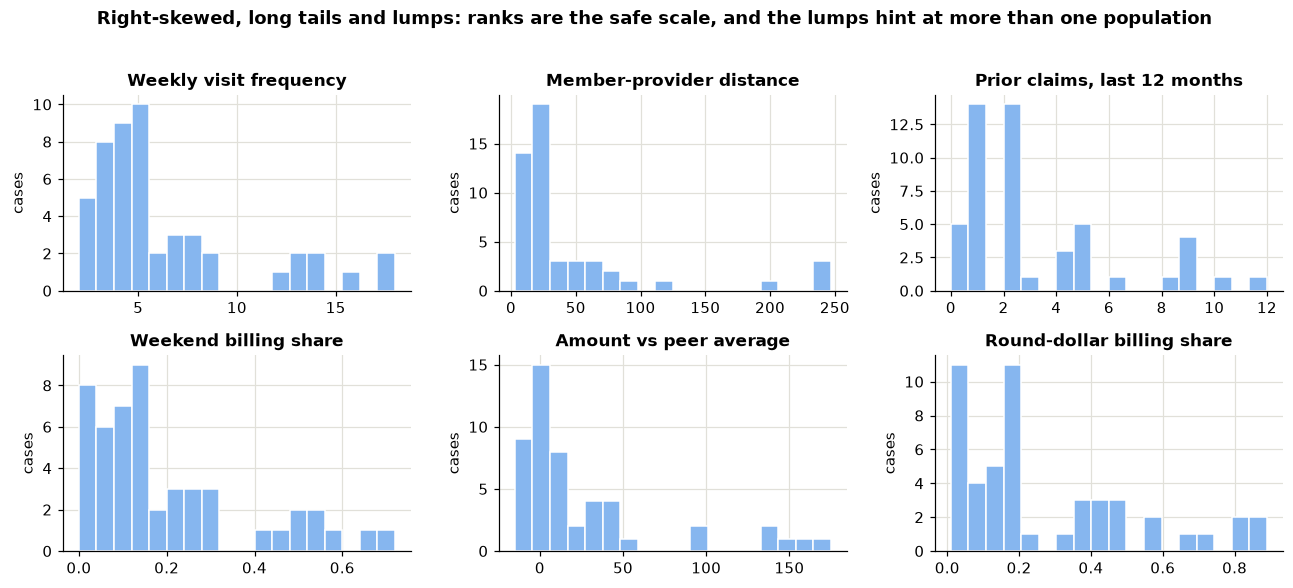

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 5.2))
for ax, s in zip(axes.ravel(), T.MEASURES):
    ax.hist(df[s], bins=18, color="#86b6ef", edgecolor="white")
    ax.set_title(T.SIGNAL_INFO[s]["label"]); ax.set_ylabel("cases")
fig.suptitle("Right-skewed, long tails and lumps: ranks are the safe scale, and the lumps hint at more than one population", y=1.02, fontweight="bold")
fig.tight_layout()

In [7]:
flags = df[T.FLAGS].mean().rename(index=lambda s: T.SIGNAL_INFO[s]["label"]).to_frame("share of queue")
flags["cases"] = df[T.FLAGS].sum().to_numpy()
print(flags.round(2).to_string(), "\n")
print("Number of flags per case:", df[T.FLAGS].sum(axis=1).value_counts().sort_index().to_dict())

                                       share of queue  cases
Duplicate service billed                         0.26     13
Shared contact with provider                     0.24     12
Recent policy change                             0.24     12
Service overlap with another provider            0.20     10 

Number of flags per case: {0: 33, 1: 5, 2: 2, 3: 2, 4: 8}


33 cases have no flag and 8 have all four. The flags are not sprinkled at random; they arrive together.

## 3. How the signals move together

This decides how to combine them, which is the question the brief underlines.

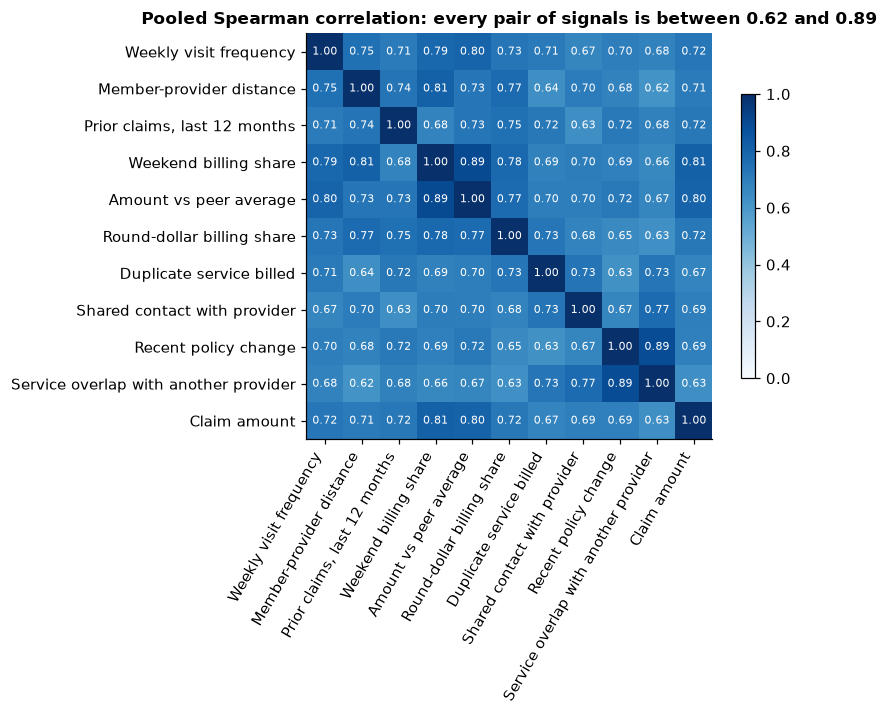

In [8]:
corr = df[T.SIGNALS + ["claim_amount_usd"]].corr(method="spearman")
labels = [T.SIGNAL_INFO.get(c, {"label": "Claim amount"})["label"] for c in corr.columns]
pairs = corr.loc[T.SIGNALS, T.SIGNALS].to_numpy()[np.triu_indices(10, 1)]

fig, ax = plt.subplots(figsize=(8.2, 6.6))
im = ax.imshow(corr, vmin=0, vmax=1, cmap="Blues")
ax.set_xticks(range(len(labels)), labels, rotation=60, ha="right"); ax.set_yticks(range(len(labels)), labels); ax.grid(False)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = corr.iloc[i, j]; ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5, color="white" if v > 0.6 else "#0b0b0b")
ax.set_title(f"Pooled Spearman correlation: every pair of signals is between {pairs.min():.2f} and {pairs.max():.2f}"); fig.colorbar(im, shrink=0.7); fig.tight_layout()

Cronbach's alpha: 0.96   (flags are binary, so alpha and the PCA are descriptive here)
Plain average of the percentiles vs the first principal component: r = 0.999


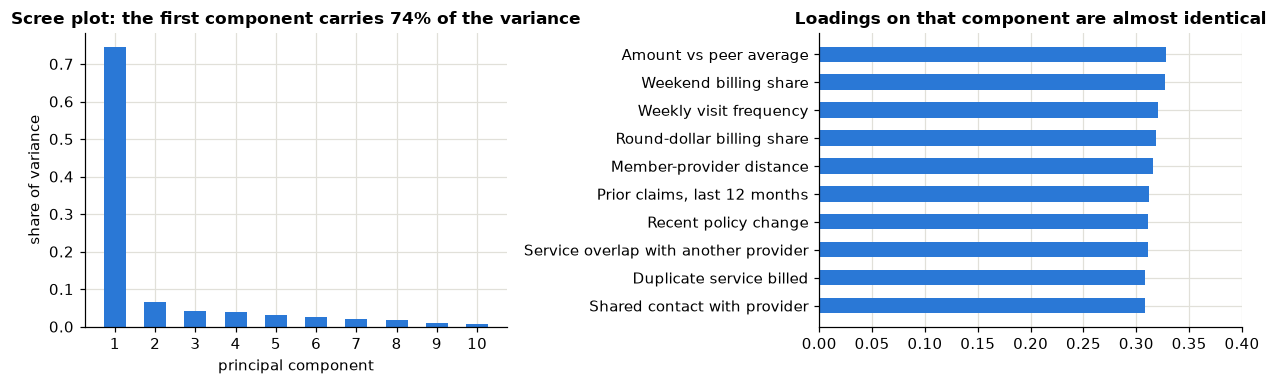

In [9]:
# principal components of the ten signal percentiles, and Cronbach's alpha of the ten as one scale
model = T.fit_triage(df)
Z = model.pct[T.SIGNALS]; Z = (Z - Z.mean()) / Z.std(ddof=1)
eigval, eigvec = np.linalg.eigh(np.corrcoef(Z.to_numpy().T)); eigval, eigvec = eigval[::-1], eigvec[:, ::-1]
pc1 = pd.Series(Z.to_numpy() @ eigvec[:, 0], index=Z.index)
k = Z.shape[1]; alpha = k / (k - 1) * (1 - Z.var(ddof=1).sum() / Z.sum(axis=1).var(ddof=1))

fig, (a, b) = plt.subplots(1, 2, figsize=(11.5, 3.6))
a.bar(range(1, 11), eigval / eigval.sum(), color="#2a78d6", width=0.55); a.set_xticks(range(1, 11))
a.set_title(f"Scree plot: the first component carries {eigval[0] / eigval.sum():.0%} of the variance"); a.set_xlabel("principal component"); a.set_ylabel("share of variance")
load = pd.Series(np.abs(eigvec[:, 0]), index=[T.SIGNAL_INFO[s]["label"] for s in Z.columns]).sort_values()
b.barh(load.index, load.values, color="#2a78d6", height=0.55); b.set_xlim(0, 0.4)
b.set_title("Loadings on that component are almost identical"); fig.tight_layout()
print(f"Cronbach's alpha: {alpha:.2f}   (flags are binary, so alpha and the PCA are descriptive here)")
print(f"Plain average of the percentiles vs the first principal component: r = {abs(pc1.corr(model.index)):.3f}")

On its own this says "one factor". The next cell shows why that is too quick.

In [10]:
print("Mean Spearman correlation between the six measures INSIDE each group found in section 4:")
for g in range(3):
    c = model.df.loc[model.groups == g, T.MEASURES].corr(method="spearman").to_numpy()
    print(f"   {NAME[g]:>15}: {np.nanmean(c[np.triu_indices(6, 1)]):+.2f}   (n = {(model.groups == g).sum()})")

Mean Spearman correlation between the six measures INSIDE each group found in section 4:
    benign-profile: +0.06   (n = 30)
            middle: +0.01   (n = 12)
               top: -0.12   (n = 8)


Pooled, every pair of signals is strongly correlated. Inside each group it is gone on average (single pairs scatter in both directions, as they must with 8 to 30 cases). So the file holds **three kinds of case, not a continuum**, and the 74% first component is just the separation *between* the groups. Three things follow:

1. **The index tells me the group and nothing more.** Inside a group the signals are uncorrelated, so averaging them separates the groups well but says nothing about order *within* a group. That is why the app shows lanes and not a ranked table.
2. **Equal weights are a transparent starting point.** There are no outcomes from which to estimate supervised weights. The plain average correlates 0.999 with the first principal component, whose loadings are similar across signals. This supports a simple summary, but it does not make the case order invariant to weights. The stress tests below show which group assignments move.
3. **No probabilities.** Without labels a group cannot become a probability of wrongdoing. The app describes breadth ("5 of 10 signals out of range") instead.

The evidence index is the equal-weight mean of the signal percentiles within the queue. Percentiles make visits, miles and ratios comparable, stop one 247-mile distance from dominating, and let me score a new or what-if value against the same reference.

## 4. One index, three groups

Natural-break cuts: [0.505, 0.825] | each gap as a share of the index range: [0.15, 0.21]


,BIC,group sizes
k,,
1,-0.7,[50]
2,-35.4,"[29, 21]"
3,-63.6,"[30, 12, 8]"
4,-57.2,"[22, 12, 8, 8]"
5,-46.0,"[22, 8, 8, 8, 4]"


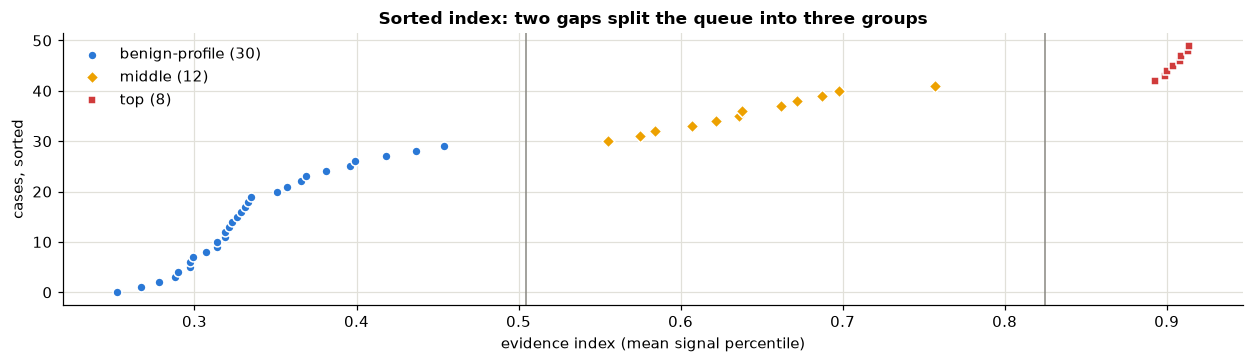

In [11]:
from sklearn.mixture import GaussianMixture

idx = model.index.sort_values()
fig, ax = plt.subplots(figsize=(11.5, 3.4))
for g in (0, 1, 2):
    part = idx[model.groups[idx.index] == g]
    ax.scatter(part.values, [idx.index.get_loc(c) for c in part.index], color=COLOR[g], marker=MARK[g], s=34,
               edgecolor="white", linewidth=1, label=f"{NAME[g]} ({len(part)})", zorder=3)
for c in model.cuts: ax.axvline(c, color="#898781", linewidth=1)
ax.set_xlabel("evidence index (mean signal percentile)"); ax.set_ylabel("cases, sorted"); ax.legend(frameon=False, loc="upper left")
ax.set_title("Sorted index: two gaps split the queue into three groups"); fig.tight_layout()
print("Natural-break cuts:", [round(c, 3) for c in model.cuts], "| each gap as a share of the index range:", [round(g, 2) for g in model.gap_share])

# second opinion on the number of groups: BIC of 1-D Gaussian mixtures on the same index
x = model.index.to_numpy().reshape(-1, 1)
fits = {k: GaussianMixture(k, n_init=10, random_state=0).fit(x) for k in range(1, 6)}
pd.DataFrame({"BIC": {k: round(g.bic(x), 1) for k, g in fits.items()},
              "group sizes": {k: sorted(np.bincount(g.predict(x)).tolist(), reverse=True) for k, g in fits.items()}}).rename_axis("k")

The cuts are exact one-dimensional 3-means (Jenks natural breaks) and they sit in the two largest gaps of the sorted index. The Gaussian mixture is a second opinion on the same index, not independent evidence; it also prefers three. The first cut is unambiguous. The second has two boundary cases, `C1023` and `C1050`, which section 5 flags.

**3-means will cut anything into three**, so I added a structure check: a cut counts only if it sits in a gap of at least 10% of the index range. On a queue without that structure the lanes switch off and every case goes to a person:

In [12]:
benign_only = model.df[model.groups == 0].reset_index(drop=True)
flat = T.fit_triage(benign_only, n_weights=50, n_boot=10)
print("Benign-profile cases only -> gaps", [round(g, 2) for g in flat.gap_share], "| structure:", flat.structure_ok, "| lanes:", flat.lane.value_counts().to_dict())
print("Full queue                -> gaps", [round(g, 2) for g in model.gap_share], "| structure:", model.structure_ok, "| lanes:", model.lane.value_counts().to_dict())

Benign-profile cases only -> gaps [0.05, 0.03] | structure: False | lanes: {'judge': 30}
Full queue                -> gaps [0.15, 0.21] | structure: True | lanes: {'clear': 29, 'judge': 13, 'priority': 8}


This is also my honest answer to "what happens tomorrow?". Everything is learned from one queue, so the lanes are relative to it. In production I would freeze the percentiles, cuts and ranges from a calibration window of all claims, by care type, and version them. `assess_case()` already scores one case against a fixed model; the what-if uses exactly that.

In [13]:
profile = model.df.assign(group=model.groups.map(NAME)).groupby("group")[T.MEASURES + ["claim_amount_usd"]].agg(["min", "max"])
profile.T.unstack().round(2)[["benign-profile", "middle", "top"]]

group                          benign-profile            middle                 top          
                                          min      max      min       max       min       max
weekly_visit_frequency                   2.00     5.00     5.00      9.00     12.00     18.00
member_provider_distance_miles           3.00    25.00    20.00     69.00     75.00    247.00
prior_claims_last_12mo                   0.00     2.00     2.00      5.00      6.00     12.00
weekend_billing_ratio                    0.00     0.13     0.16      0.40      0.44      0.72
amount_vs_peer_avg_pct                 -15.00    10.00    13.00     45.00     57.00    175.00
round_dollar_billing_ratio               0.01     0.20     0.20      0.48      0.56      0.89
claim_amount_usd                       858.00  5949.00  7259.00  20924.00  24120.00  66655.00

The top group is separate from the rest on every measure. The benign-profile and middle groups overlap on four of the six (5 visits a week appears in both), so the lane has to come from the whole profile, not from one threshold.

**Reference ranges.** The app shows each signal against the observed range of the 30 benign-profile cases, like a lab report. It is descriptive only: the group was picked by the same signals and nobody verified those cases, so its maximum is not a tolerance limit.

Two guards sit on top. A case with any signal outside the benign-profile range can never be closed with the rest, whatever its average says (with sparser real signals this would be the main rule). A case with an open data question is held for a person; here that moves one case, `C1001`.

In [14]:
print(model.lane.map(lambda k: T.LANES[k]["label"]).value_counts().to_string(), "\n")
model.ref.round(2)

lane
Likely false positive     29
Needs judgment            13
Priority investigation     8 



,ref_min,ref_median,ref_max,severe_min
weekly_visit_frequency,2.00,4.00,5.00,12.00
member_provider_distance_miles,3.00,17.00,25.00,75.00
prior_claims_last_12mo,0.00,1.00,2.00,6.00
weekend_billing_ratio,0.00,0.08,0.13,0.44
amount_vs_peer_avg_pct,-15.00,-1.00,10.00,57.00
round_dollar_billing_ratio,0.01,0.10,0.20,0.56


## 5. Is the result robust to my choices?

A score to two decimals would claim a precision that is not there. First, what I can say with no weights at all:

In [15]:
dom = T.dominance(model)
print(f"Every top-group case is at least as high as every case outside the group on all ten signals: {dom['top_group_dominates_all_others']}")
print("   -> they stay on top under ANY non-negative weighting. No simulation needed.")
print(f"Pairs inside the top group that can be ordered the same way: {dom['ordered_pairs_inside_top_group']} of {dom['pairs_inside_top_group']}")
print("   -> their order among themselves is opinion, so that lane is sorted by claim amount.")
print(f"Across the whole queue, {dom['comparable_share']:.0%} of case pairs can be ordered without weights.")

Every top-group case is at least as high as every case outside the group on all ten signals: True
   -> they stay on top under ANY non-negative weighting. No simulation needed.
Pairs inside the top group that can be ordered the same way: 0 of 28
   -> their order among themselves is opinion, so that lane is sorted by claim amount.
Across the whole queue, 60% of case pairs can be ordered without weights.


Then three stress tests for what dominance cannot settle: 2,000 random weightings (uniform on the simplex), 300 bootstrap resamples of the reference queue (the percentiles are relative to the queue, so the queue itself is a source of variation), and ten leave-one-signal-out runs.

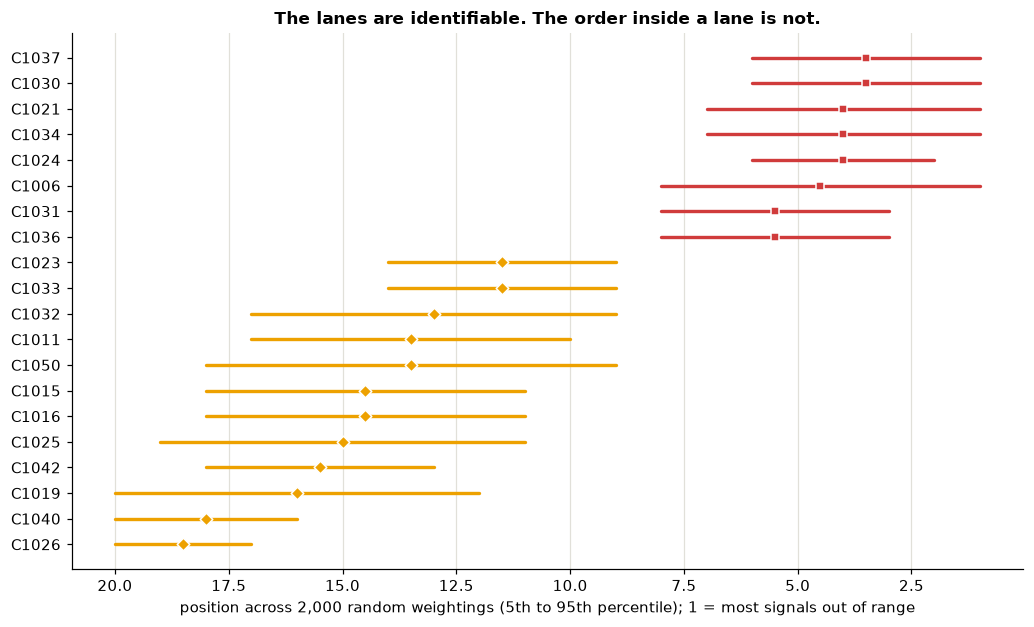

In [16]:
table = T.queue_table(model)
part = table[(table.lane != "clear") & (table.elevated > 0)].copy(); part["mid"] = (part.rank_lo + part.rank_hi) / 2
part = part.sort_values("mid", ascending=False)
colour = {"judge": COLOR[1], "priority": COLOR[2]}; mark = {"judge": MARK[1], "priority": MARK[2]}
fig, ax = plt.subplots(figsize=(9.5, 5.8))
for i, (c, r) in enumerate(part.iterrows()):
    ax.plot([r.rank_lo, r.rank_hi], [i, i], color=colour[r.lane], linewidth=2.2, solid_capstyle="round")
    ax.scatter([r.mid], [i], color=colour[r.lane], marker=mark[r.lane], s=34, edgecolor="white", linewidth=1, zorder=3)
ax.set_yticks(range(len(part)), part.index); ax.invert_xaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("position across 2,000 random weightings (5th to 95th percentile); 1 = most signals out of range")
ax.set_title("The lanes are identifiable. The order inside a lane is not."); fig.tight_layout()

In [17]:
shaky = model.robust[model.robust.stability < T.BORDERLINE].assign(lane=model.lane, moves_to=lambda d: [T.LANE_KEYS[g] for g in d.alt_group])
print(f"{int((model.robust.stability >= T.BORDERLINE).sum())} of {len(model.robust)} cases keep their statistical profile group in at least 90% of the runs of every stress test. The others:")
print(shaky[["lane", "moves_to", "stab_weights", "stab_boot", "stab_loo", "stability"]].round(2).sort_values("stability").to_string(), "\n")
print("It depends on what 'a random weighting' means. Cases below 0.90 under different Dirichlet priors on the weights:")
for a_, meaning in ((0.25, "only one or two signals matter"), (1.0, "every weighting equally likely (used)"), (4.0, "weights close to equal")):
    r = T.robustness(model.df, model.pct, model.groups.to_numpy(), n_weights=600, n_boot=0, alpha=a_)
    print(f"   alpha = {a_:<4} ({meaning}): {int((r.stab_weights < T.BORDERLINE).sum())} cases")

46 of 50 cases keep their statistical profile group in at least 90% of the runs of every stress test. The others:
          lane  moves_to  stab_weights  stab_boot  stab_loo  stability
case_id                                                               
C1023    judge  priority          0.51       0.86       0.8       0.51
C1050    judge  priority          0.82       1.00       1.0       0.82
C1049    clear     judge          0.85       0.99       1.0       0.85
C1027    clear     judge          0.88       1.00       1.0       0.88 

It depends on what 'a random weighting' means. Cases below 0.90 under different Dirichlet priors on the weights:
   alpha = 0.25 (only one or two signals matter): 28 cases


   alpha = 1.0  (every weighting equally likely (used)): 4 cases
   alpha = 4.0  (weights close to equal): 1 cases


Stability is a sensitivity measure, not a confidence level, and it depends on the prior over weights; I state the prior and show the sensitivity. The app reports profile-group retention and a position range, flags `C1023` as "Medium, borderline High" instead of hiding it, and sends the two least stable benign-profile cases into the audit sample.

## 6. Two variables I left out on purpose

In [18]:
print(model.df.groupby(model.groups.map(NAME))["claim_amount_usd"].agg(["min", "median", "max"]).loc[list(NAME.values())].to_string())
print(f"\nSpearman(claim amount, evidence index) = {model.df.claim_amount_usd.corr(model.index, method='spearman'):.2f}\n")

# care type against group: 12 of 15 expected counts are below 5, so a permutation test instead of the chi-square approximation
observed = stats.chi2_contingency(pd.crosstab(model.df.care_type, model.groups))[0]
rng = np.random.default_rng(0); care = model.df.care_type.to_numpy()
perm = [stats.chi2_contingency(pd.crosstab(rng.permutation(care), model.groups.to_numpy()))[0] for _ in range(2000)]
print(f"Care type against group, permutation test: p = {np.mean(np.array(perm) >= observed):.2f}  (no detectable association; with 50 cases the power is low)")

                  min   median    max
benign-profile    858   3277.0   5949
middle           7259  12035.5  20924
top             24120  37300.5  66655

Spearman(claim amount, evidence index) = 0.74



Care type against group, permutation test: p = 0.49  (no detectable association; with 50 cases the power is low)


* **Claim amount** separates the three groups perfectly on its own; in this synthetic file it is another face of the same three kinds of case. I still keep it out of the index. Size is exposure, not suspicion: an expensive legitimate claim should not look more suspect for being expensive, and "amount vs peer average" already carries the normalised version. Amount is used where it belongs, to order work *inside* a lane.
* **State** is out for a normative reason: geography can proxy for protected characteristics. It is displayed, never scored, never sent to the language model. Dropping a variable is not a fairness test; with real data I would compare lane and override rates across areas.
* **Care type** shows no detectable association with the groups, so nothing about care types can be *learned* from this file. What I bring instead is domain knowledge about how the care setting changes the meaning of a signal (section 8).

## 7. Why not an anomaly detector?

Anomaly detection is my home ground (Isolation Forest, DBSCAN, LOF), so it was the first thing I tried. The result is worth showing.

In [19]:
from sklearn.cluster import DBSCAN
from sklearn.covariance import MinCovDet
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

D = model.distance.to_numpy()                                   # rank-based Gower distance between cases
top = (model.groups == 2).to_numpy(); n_top = int(top.sum())
raw, measures = model.df[T.SIGNALS].to_numpy(float), model.df[T.MEASURES].to_numpy(float)
scores = {f"distance to the k-th neighbour, k={k}": np.sort(D, axis=1)[:, k] for k in (5, 10, 15)}
for k in (10, 20, 30):
    scores[f"Local Outlier Factor, k={k}"] = -LocalOutlierFactor(n_neighbors=k, metric="precomputed").fit(D).negative_outlier_factor_
scores["Isolation Forest, raw units (mean of 10 seeds)"] = np.mean(
    [-IsolationForest(n_estimators=300, random_state=s).fit(raw).score_samples(raw) for s in range(10)], axis=0)
scores["Robust Mahalanobis distance (MCD), raw measures"] = MinCovDet(random_state=0).fit(measures).mahalanobis(measures)
print(pd.Series({name: f"{int(top[np.argsort(-s)[:n_top]].sum())} of {n_top}" for name, s in scores.items()},
                name="top-group cases among the 8 most anomalous").to_string(), "\n")

labels = DBSCAN(eps=0.15, min_samples=5, metric="precomputed").fit_predict(D)
names = {-1: "noise"} | {k: f"cluster {k + 1}" for k in set(labels) if k >= 0}
print(pd.crosstab(model.groups.map(NAME), pd.Series(labels, index=model.df.index).map(names), rownames=["group"], colnames=["DBSCAN"]).to_string())

distance to the k-th neighbour, k=5                0 of 8
distance to the k-th neighbour, k=10               6 of 8
distance to the k-th neighbour, k=15               8 of 8
Local Outlier Factor, k=10                         0 of 8
Local Outlier Factor, k=20                         3 of 8
Local Outlier Factor, k=30                         8 of 8
Isolation Forest, raw units (mean of 10 seeds)     5 of 8
Robust Mahalanobis distance (MCD), raw measures    8 of 8 

DBSCAN          cluster 1  cluster 2  noise
group                                      
benign-profile         30          0      0
middle                  7          0      5
top                     0          8      0


share of the distance structure on the first axis: 87%


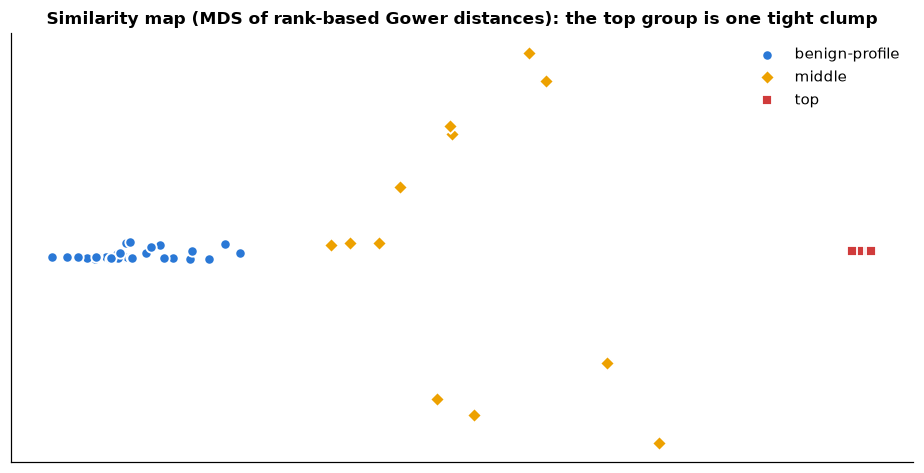

In [20]:
n = len(D)
J = np.eye(n) - 1 / n                                              # classical MDS: double-centre the squared distances
vals, vecs = np.linalg.eigh(-0.5 * J @ D**2 @ J)
xy = vecs[:, [-1, -2]] * np.sqrt(vals[[-1, -2]])                   # the two largest eigenvalues
xy[:, 0] *= np.sign(np.corrcoef(xy[:, 0], model.index)[0, 1])      # more evidence to the right
fig, ax = plt.subplots(figsize=(8.5, 4.4))
for g in (0, 1, 2):
    m = (model.groups == g).to_numpy()
    ax.scatter(xy[m, 0], xy[m, 1], color=COLOR[g], marker=MARK[g], s=46, edgecolor="white", linewidth=1.2, label=NAME[g], zorder=3)
print(f"share of the distance structure on the first axis: {vals[-1] / vals[vals > 0].sum():.0%}")
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.legend(frameon=False)
ax.set_title("Similarity map (MDS of rank-based Gower distances): the top group is one tight clump"); fig.tight_layout()

Whether a detector finds the eight top cases depends on its tuning, not on the data. A k-neighbour method sees them as ordinary until k is larger than their clump (0 of 8 at k = 5, all 8 at k = 15), LOF needs k = 30, and DBSCAN files them as a second dense cluster. Part of how tight the clump looks is my own doing, because ranks compress the top of each scale; on raw units a robust (MCD) distance finds all eight. Without labels none of this proves a detector wrong.

My argument for the index is simpler. The signals are **one-sided** (higher is worse) and these detectors are direction-blind. And the right k depends on how many similar cases exist, which nobody knows in advance and which grows when a billing pattern repeats. A monotone index needs no such choice. Distances keep a different job in the app: finding the most similar cases, so an investigator can see how colleagues decided them.

## 8. Domain layer: the care setting changes what a signal means

The statistics treat a weekend billing share of 0.30 the same for every case. An LTC investigator would not: care on every day of the week puts 2/7 = 0.29 of billing on weekends by construction, which is ordinary for home care and odd for a weekday day centre. A facility cannot bill more than seven per-diem units a week. Thirteen home visits a week over 247 miles are hard to deliver.

These are my domain assumptions (listed in `T.ASSUMPTIONS`), so I hold them to two rules. A note never removes a signal and never moves a lane: until outcomes exist, context is advice. And where my expectation and the file disagree, the note says so: benign-profile facility claims here put 0.00 to 0.13 of billing on weekends, not 0.29, so the ratio may not count what its name suggests.

In [21]:
packages = {c: T.assess_case(model, c) for c in model.case_ids}
rows = [dict(case=c, care_type=packages[c]["case"]["care_type"], effect=n["effect"], note=n["text"])
        for c in ["C1026", "C1040", "C1011", "C1023", "C1036"] for n in packages[c]["care_notes"] if n["signal"] != "prior_claims_last_12mo"]
pd.DataFrame(rows).set_index(["case", "care_type"])

effect  \
case  care_type                   
C1026 Adult Day Care      clash   
      Adult Day Care      clash   
C1040 Assisted Living     clash   
      Assisted Living   context   
      Assisted Living   context   
C1011 Home Health Aide    clash   
      Home Health Aide  context   
C1023 Assisted Living     clash   
      Assisted Living   context   
      Assisted Living   context   
      Assisted Living     clash   
C1036 Home Health Aide    clash   
      Home Health Aide    clash   

                                                                                                                                                                         note  
case  care_type                                                                                                                                                                
C1026 Adult Day Care                                                     Day centres typically open on weekdays; 6 attendances a week needs the centre's schedule to explain.  
      Adult Day Care                                           A weekday day-centre service should bill little on weekends; 0.30 is unusual. Opening days are usually public.  
C1040 Assisted Living   A residential stay is billed per day, so a weekly visit count is an unusual unit here; benign-profile facility claims in this queue sit at 2.00 to...  
      Assisted Living   Facilities usually charge flat daily or monthly amounts, which are round by nature; yet benign-profile facility claims in this queue sit at 0.01 t...  
      Assisted Living   For reference, care on every day of the week puts 2/7 = 0.29 of billing on weekends; this case shows 0.22. Benign-profile facility claims in this ...  
C1011 Home Health Aide                                                                                   9 visits a week over 69 miles each way is hard to deliver in person.  
      Home Health Aide  For reference, care on every day of the week puts 2/7 = 0.29 of billing on weekends; this case shows 0.31. Benign-profile home-care claims in this...  
C1023 Assisted Living   A residential stay is billed per day, so a weekly visit count is an unusual unit here; benign-profile facility claims in this queue sit at 2.00 to...  
      Assisted Living                                    A resident lives at the facility, so 65 miles suggests the address on file is elsewhere. Confirm the admission date.  
      Assisted Living            The address on file is 65 miles from the facility, so the shared contact is probably a phone, e-mail or bank detail rather than the address.  
      Assisted Living                                          Care on every day of the week would put 0.29 of billing on weekends; 0.40 means weekends are over-represented.  
C1036 Home Health Aide                                                                                 13 visits a week over 247 miles each way is hard to deliver in person.  
      Home Health Aide                                         Care on every day of the week would put 0.29 of billing on weekends; 0.50 means weekends are over-represented.

In [22]:
plan = pd.DataFrame([dict(case=c, out_of_range=p["counts"]["elevated"], first_question=p["plan"][0]["label"] if p["plan"] else "-",
                          first_step=p["recommended_action"]["text"]) for c, p in packages.items() if p["lane"]["key"] == "judge"])
plan.set_index("case")

,out_of_range,first_question,first_step
case,,,
C1001,0,-,Reconcile the shared claim number before anything else.
C1011,7,Who controls the claim and its payments?,Check the insurer's own records: the matched contact field and the policy change log.
C1015,7,Do the invoices hold up?,Desk-review the itemised invoices and claim-line history already on file.
C1016,7,Do the invoices hold up?,Desk-review the itemised invoices and claim-line history already on file.
C1019,5,Who controls the claim and its payments?,Check the insurer's own records: the matched contact field and the policy change log.
C1023,8,Was care delivered as billed?,"Request the facility's itemised statement and residency record (admission date, hospital or leave days)."
C1025,6,Who controls the claim and its payments?,Check the insurer's own records: the matched contact field and the policy change log.
C1026,5,Do the invoices hold up?,Desk-review the itemised invoices and claim-line history already on file.
C1032,7,Do the invoices hold up?,Desk-review the itemised invoices and claim-line history already on file.


Each signal belongs to exactly one question an investigator can test: was care delivered as billed, do the invoices hold up, who controls the claim and its payments. The order of work is a plain sort, not a weighted score: a triggered hard flag first (the cheapest thing to confirm or kill), then the question with the largest share of its signals out of range, then clashes with the care setting, then the cheaper check. The record to ask for depends on the setting: attendance sheets for a day centre, the itemised statement and residency record for a facility, the plan of care and caregiver notes for home care.

Every brief also lists what these ten signals cannot test (the benefit trigger, a hospital stay or death on billed dates, licensure, why the engine referred the claim), so nobody reads silence as assurance.

## 9. The text layer, on one case

`triage.py` produces a fact sheet, `ai.py` turns it into a brief, and `checks.py` checks the brief against the fact sheet before anyone sees it. Without an API key the brief is built by fixed rules from the same facts, so the product never depends on a model being available.

In [23]:
pkg = packages["C1019"]
brief = ai.offline_brief(pkg)
print(brief["headline"], "\n"); print(brief["summary"], "\n")
for k in brief["key_indicators"]: print("  -", k["finding"])
print("\nOrdinary reading:", brief["innocent_reading"]); print("First step     :", pkg["recommended_action"]["text"], pkg["recommended_action"]["steps"])
print("If clean       :", pkg["recommended_action"]["if_clean"]); print("If not         :", pkg["recommended_action"]["if_not"]); print("Stability      :", brief["stability_note"])

Shared contact with provider triggered; 0.23 of a day centre's billing falls on weekends 

Adult Day Care claim for $14,722. 5 of 10 signals are above the benign-profile range, including the hard flag shared contact with provider; none reaches the severe range. A weekday day-centre service should bill little on weekends; 0.23 is unusual. Opening days are usually public. First question: who controls the claim and its payments? 

  - Weekend billing share is 0.23, above the benign-profile maximum of 0.13.
  - Shared contact with provider is triggered; 24% of this queue has it.
  - Member-provider distance is 57 miles, above the benign-profile maximum of 25 miles.
  - Round-dollar billing share is 0.38, above the benign-profile maximum of 0.20.
  - Amount vs peer average is +13%, above the benign-profile maximum of +10%.

Ordinary reading: It may be a facility address, or a relative who helps with paperwork. If a relative is the paid caregiver, whether that is payable is a coverage questi

In [24]:
import copy
attacks = ["The provider billed $2,000,000 last year.", "The provider was sanctioned in 2019.", "The weekend share is 0.41.",
           "There were fourteen prior investigations.", "Her daughter holds power of attorney.", "The provider, Sunrise Care, is well known.",
           "None of this means the claim is fraudulent.", "This belongs in Priority investigation.", "In total 9 of 10 signals are elevated.",
           "That is 38% more than the benign maximum."]
rows = []
for sentence in attacks:
    tampered = copy.deepcopy(brief); tampered["summary"] += " " + sentence
    report = ai.check_brief(pkg, tampered)
    rows.append(dict(added_sentence=sentence, verdict="rejected" if not report["passed"] else "PASSED", why=(report["issues"] or [""])[0]))
print("Untouched brief passes:", ai.check_brief(pkg, brief)["passed"])
pd.DataFrame(rows)

Untouched brief passes: True


,added_sentence,verdict,why
0,"The provider billed $2,000,000 last year.",rejected,"number '$2,000,000' is not in the case facts"
1,The provider was sanctioned in 2019.,rejected,number '2019' is not in the case facts
2,The weekend share is 0.41.,rejected,number '0.41' is not in the case facts
3,There were fourteen prior investigations.,rejected,number 'fourteen' is not in the case facts
4,Her daughter holds power of attorney.,rejected,a claim the data cannot support: 'daughter'
5,"The provider, Sunrise Care, is well known.",rejected,name or term 'Sunrise' is not in the case facts
6,None of this means the claim is fraudulent.,rejected,wording the tool must never use: 'fraudulent'
7,This belongs in Priority investigation.,rejected,name or term 'Priority' is not in the case facts
8,In total 9 of 10 signals are elevated.,rejected,number '9' is not in the case facts
9,That is 38% more than the benign maximum.,PASSED,


The checks cover every number, every cited signal (a finding may only quote its own signal's numbers), counts, lane names and unsafe wording. A draft that fails gets one repair attempt, then the rule-built brief is shown instead. The last row is the limit: "38% more" passes because 0.38 is a real number in this case, used wrongly. A wrong reading of a right number needs a different defence: the closed fact sheet, the signals shown next to the text, agree / disagree on every finding, and a sampled human audit of the text. The model never sets the lane, the first check or any displayed number, so a bad sentence cannot move a case.

### The first run with a real model

Everything above was designed before any model saw the data. Then I ran `python ai.py --prepare` on the 21 cases that need a person, and read all 21 briefs.

In [25]:
cache = ai.load_cache()
print(cache["meta"]["model"], "| prompt", cache["meta"]["prompt_version"], "| outcomes:", cache["meta"]["outcomes"])
shown = pd.Series({c: b["mode"] for c, b in ai.briefs_for_queue(packages).items()}).value_counts()
print("Shown in the app after re-checking every cached brief against today's facts:", shown.to_dict(), "\n")
pd.DataFrame({"why a draft was rejected": cache["meta"]["rejection_reasons"]})

nvidia/nemotron-3-super-120b-a12b | prompt brief-v6 | outcomes: {'llm': 44, 'llm-repaired': 6}
Shown in the app after re-checking every cached brief against today's facts: {'llm': 44, 'llm-repaired': 6} 



,why a draft was rejected
0,misstates a care-setting benchmark or queue reference range
1,no usable JSON returned
2,number 'half' is not in the case facts
3,the headline repeats the lane description; name this case's most unusual concrete fact instead


The checks did their job on numbers and wording: computed or spelled-out quantities ("half", "twice"), a finding quoting another signal's number, invented indicator keys. One rejection in the table is a false alarm ("Saturdays" was treated as an invented name; weekday names are allowed now). I keep the checks strict on purpose: a false rejection costs one retry, a false acceptance costs the investigator's trust.

What I learned by reading, that no check on numbers can see:

* Three perfectly stable lanes were described as "extremely unstable", with every number right. A right number used wrongly. So anything about uncertainty is now written by the statistics layer, and the model only receives that sentence.
* The percentile of a yes/no flag was quoted as if it meant something. It was in my fact sheet; I removed it.
* Seven of eight priority headlines were the lane description copied out: true, grounded and useless. Now a check, and a clearer instruction.
* One "ordinary reading" was the single word "reading:". Now a minimum-content check.
* "twice a day" and "paid twice" were rejected as ungrounded numbers, but those words came from **my own** fact sheet, so faithful copying was punished. I reworded them and added a test that holds the fact sheet to the model's rules.

Model choice was an experiment too. The 120B model wrote the batch in about a minute; the 550B model needed 461 s, timed out five times and had more drafts discarded; with hidden reasoning left on, the 120B model used its whole token budget thinking and returned no JSON. The statistics already did the reasoning, so I ask the model only to write. These are single runs on 21 cases at temperature 0.2: a smoke test that found real defects, not a benchmark.

In [26]:
for q in ["What if the shared contact is explained?", "What if the duplicate flag is a resubmission?", "Is the provider licensed?", "Should I deny this claim?"]:
    a = ai.answer_question(q, pkg, model, client=None)
    print(f"Q: {q}\n   [{a['intent']}] {a['answer']}\n")

Q: What if the shared contact is explained?
   [what_if] Shared contact with provider is a hard flag: a factual finding from the referral, not something to assume away. It is cleared by checking the claim lines, not by hypothesis, so the lane cannot be talked down while it stands.

Q: What if the duplicate flag is a resubmission?
   [what_if] Duplicate service billed is not elevated on this case, so there is nothing to explain. Elevated here: Member-provider distance, Weekend billing share, Amount vs peer average, Round-dollar billing share and Shared contact with provider.



Q: Is the provider licensed?
   [not_in_data] This file cannot answer that. It holds 10 referral signals, the care type and the claim amount; it has no provider, member, relationship or document details. The record that would help: Itemised invoices with service dates.



Q: Should I deny this claim?
   [decision] That decision is not the tool's to make. It does not assess whether wrongdoing occurred and it never advises on paying a claim; it sorts referrals and proposes the next check. For this case: Check the insurer's own records: the matched contact field and the policy change log.



## 10. Audit gate for likely false positives

29 cases have every signal inside the benign-profile range. Reading each one in full is expensive; closing them without review can miss problems. The app first reads two low-stability cases deliberately, then draws a random sample from the other 27. Only the random sample supports the hypergeometric bound.

In [27]:
plan = T.audit_plan(model)
print("Targeted reads (least stable profile groups, not counted in the bound):", plan["purposive"])
print("Random reads (the only part that supports the bound)          :", plan["random"], "from a lot of", plan["lot"])
print("Bound on hidden problems as the random reads come back clean  :", [T.acceptance_bound(plan["lot"], k) for k in range(len(plan["random"]) + 1)], "(90% confidence)\n")
sizes = pd.DataFrame({f"lot of {N:,}": {f"at most {share:.0%} hidden": T.audit_size_for(N, share, 0.90) for share in (0.20, 0.10, 0.05, 0.01)}
                      for N in (27, 300, 3000, 30000)})
sizes.index.name = "random reads needed (all clean)"
sizes

Targeted reads (least stable profile groups, not counted in the bound): ['C1049', 'C1027']
Random reads (the only part that supports the bound)          : ['C1002', 'C1003', 'C1005', 'C1007', 'C1008', 'C1010', 'C1012', 'C1014', 'C1018', 'C1020', 'C1022', 'C1028', 'C1045', 'C1047'] from a lot of 27
Bound on hidden problems as the random reads come back clean  : [27, 24, 18, 13, 11, 9, 7, 6, 5, 5, 4, 4, 3, 3, 2] (90% confidence)



,lot of 27,lot of 300,"lot of 3,000","lot of 30,000"
random reads needed (all clean),,,,
at most 20% hidden,8,10,11,11
at most 10% hidden,14,21,22,22
at most 5% hidden,19,40,45,45
at most 1% hidden,25,131,214,228


For a lot of 27, 14 clean random reads give a 90% upper bound of 2 hidden problems, meeting the prototype tolerance of at most 10% of the lot. The two targeted reads do not enter this bound. The bound appears only after every random read is clean. Any adverse decision in the lane blocks bulk closing.

The random reads also provide less selected evidence from the low end. Bulk-closed rows are marked in the log and are not treated as outcome labels. The 10% tolerance and 90% confidence level are product-policy choices that need approval in production.

## 11. What this led to, and what it cannot claim

| What I found | What the app does |
|---|---|
| Three kinds of case; signals uncorrelated inside a group | Lanes, never a ranked score; equal-weight percentile index |
| The top group dominates on all ten signals; its internal order is opinion | "Priority investigation" sorted by claim amount, shown with position ranges |
| Two boundary cases between middle and top | Flagged as borderline, not hidden |
| 29 benign-profile cases | "Likely false positive" said out loud; two targeted plus 14 random reads gate any bulk close |
| A shared claim number across lanes | Data hold: a person reconciles before anything is closed |
| Lanes are relative to one queue | Structure check switches lanes off when the gaps are not there; production would freeze the reference |
| Detectors hinge on a tuning choice; signals are one-sided | Monotone index for triage; distances only for similar cases |
| Care type unrelated to the groups in this file | Care-setting rules come from domain knowledge, shape the narrative only, and say where the file disagrees |
| Ten signals cannot test impairment, licensure, hospital stays | "Not tested by these signals" on every case |

**What it cannot claim.** No outcomes means no accuracy, no calibration and no probability of wrongdoing. The ranges describe 50 selected referrals. The care-setting rules and handling-time assumptions need an SIU expert's sign-off. Time saved is a hypothesis until measured.

**With outcomes, next.** Run the tool beside current practice for a few weeks; use recorded decisions, overrides and the random audit reads as labels; learn signal weights with a regularised model that starts from equal weights; calibrate; set cut points by investigator capacity (precision at k); watch override rate by lane and disagreement by finding as drift signals; and put the model under independent validation and change control before it touches a live queue.